In [1]:
# 1 — Load the two-year base and map every foreign port to a region
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

candidates = [Path.cwd(), *Path.cwd().parents]
BASE = next((p for p in candidates if (p / "data" / "processed").exists()), None)
if BASE is None:
    raise FileNotFoundError(f"data/processed not found from {Path.cwd()} - run from inside the project folder.")
PROC = BASE / "data" / "processed"

# keep_default_na=False: otherwise pandas reads Namibia's country code "NA" as a missing value
flows = pd.read_csv(PROC / "trade_flows_2024_2025.csv.gz", keep_default_na=False, na_values=[""])
calls = pd.read_csv(PROC / "calls_2024_2025.csv")

REGIONS = {
    "Asia": "CN HK MO TW KR KP JP VN TH MY ID PH KH MM BD BN".split(),
    "Middle East & South Asia": "IN PK LK MV AE SA OM QA KW BH IR IQ JO IL LB SY YE".split(),
    "Europe": ("PT ES FR IT DE NL BE LU GB IE DK SE NO FI IS PL CZ SK AT CH HU SI HR BA RS ME AL MK "
               "GR CY MT TR RO BG MD UA BY RU LT LV EE GE GI").split(),
    "North America": "US CA BM".split(),
    "Latin America & Caribbean": ("MX GT BZ HN SV NI CR PA CU DO HT JM BS TT BB GD LC VC AG KN DM "
                                  "PR AW CW BQ SX AN KY TC VG VI GP MQ GF GY SR CO VE EC PE BO CL AR UY PY").split(),
    "Africa": ("MA DZ TN LY EG SD MR SN GM GW GN SL LR CI GH TG BJ NG CM GQ GA CG CD AO NA ZA LS SZ BW "
               "MZ TZ KE SO DJ ER MG MU RE YT KM SC CV ST").split(),
    "Oceania": "AU NZ PG FJ NC PF TO".split(),
}
HUB_PORTS = {"MAPTM", "MATNG", "ESALG", "LKCMB", "COCTG", "JMKIN"}   # MATNG: Tanger Med under the old Tangier code
HUB_COUNTRIES = {"SG", "PA"}
UNKNOWN_CC = {"XZ", "ZZ"}
CC_TO_REGION = {cc: r for r, ccs in REGIONS.items() for cc in ccs}

def to_region(port, cc):
    if cc in UNKNOWN_CC:
        return "Not identified"
    if port in HUB_PORTS or cc in HUB_COUNTRIES:
        return "Transhipment hub"
    return CC_TO_REGION.get(cc, "Unmapped")

flows["region"] = [to_region(p, c) for p, c in zip(flows["foreign_port"], flows["foreign_cc"])]

unmapped = flows[flows["region"] == "Unmapped"].groupby("foreign_cc", dropna=False)["teu"].sum().sort_values(ascending=False)
print(f"Unmapped countries: {len(unmapped)} | {unmapped.sum():,.0f} TEU", unmapped.head(10).round(0).to_dict(), "\n")

hub_check = flows[flows["region"] == "Transhipment hub"].groupby("foreign_port")["teu"].sum().sort_values(ascending=False)
print("Hub codes found (TEU thousands, both years):", (hub_check.head(10) / 1e3).round(1).to_dict())
print("Hub port codes missing from the data:", sorted(HUB_PORTS - set(hub_check.index)), "\n")

region_teu = flows.groupby(["region", "year"])["teu"].sum().unstack("year")
print("All deep-sea trade by region (TEU, thousands):")
print((region_teu / 1e3).round(0).sort_values(2025, ascending=False).to_string(), "\n")

top = (flows[flows["year"] == 2025].groupby(["region", "foreign_port"])["teu"].sum()
       .groupby(level=0, group_keys=False).nlargest(3) / 1e3).round(1)
print("Top 3 foreign ports per region, 2025 (TEU, thousands):")
print(top.to_string())

assert abs(region_teu.fillna(0).to_numpy().sum() - flows["teu"].sum()) < 1, "regions do not add up to the total"
print("\nCheck passed: regions add up to the total.")

Unmapped countries: 0 | 0 TEU {} 

Hub codes found (TEU thousands, both years): {'SGSIN': 1579.3, 'MAPTM': 846.8, 'COCTG': 790.5, 'ESALG': 341.6, 'PACTB': 261.0, 'MATNG': 259.7, 'JMKIN': 220.1, 'LKCMB': 142.6, 'PAMIT': 128.6, 'PAONX': 30.8}
Hub port codes missing from the data: [] 

All deep-sea trade by region (TEU, thousands):
year                         2024    2025
region                                   
Asia                       2696.0  3391.0
Transhipment hub           2294.0  2310.0
Europe                     1368.0  1390.0
Latin America & Caribbean   914.0   984.0
North America               775.0   749.0
Africa                      205.0   236.0
Middle East & South Asia    114.0   200.0
Not identified               17.0    81.0
Oceania                       3.0     3.0 

Top 3 foreign ports per region, 2025 (TEU, thousands):
region                     foreign_port
Africa                     AOLAD            60.3
                           ZADUR            41.4
            

In [2]:
# 2 — Where dry empties go and where reefer empties come from, by region (TEU, thousands)
def by_region_year(mask):
    t = (flows[mask].groupby(["region", "year"])["teu"].sum() / 1e3).unstack("year").fillna(0)
    t["change"] = t[2025] - t[2024]
    t["change_%"] = (100 * (t[2025] / t[2024] - 1)).replace([np.inf, -np.inf], np.nan)
    t["share_2025_%"] = 100 * t[2025] / t[2025].sum()
    return t.sort_values(2025, ascending=False).round(1)

is_exp, is_imp = flows["direction"] == "Export", flows["direction"] == "Import"
is_dry, is_reefer = flows["equip"] == "dry", flows["equip"] == "reefer"
is_empty = flows["state"] == "Empty"

print("Dry EMPTY exports by region:")
print(by_region_year(is_exp & is_dry & is_empty).to_string(), "\n")

print("Reefer EMPTY imports by region:")
print(by_region_year(is_imp & is_reefer & is_empty).to_string(), "\n")

exp_dry = flows[is_exp & is_dry].groupby(["region", "year", "state"])["teu"].sum().unstack("state").fillna(0)
exp_dry["empty_share_%"] = 100 * exp_dry["Empty"] / (exp_dry["Empty"] + exp_dry["Full"])
print("Share of outbound DRY boxes that leave empty, by region (%):")
print(exp_dry["empty_share_%"].unstack("year").round(1).sort_values(2025, ascending=False).to_string(), "\n")

cn = flows[flows["foreign_cc"] == "CN"]
cn_tab = (cn.groupby(["direction", "equip", "state", "year"])["teu"].sum() / 1e3).unstack("year").fillna(0).round(0)
cn_tab["change_%"] = (100 * (cn_tab[2025] / cn_tab[2024] - 1)).replace([np.inf, -np.inf], np.nan).round(1)
print("China only (TEU, thousands):")
print(cn_tab.to_string())

Dry EMPTY exports by region:
year                        2024   2025  change  change_%  share_2025_%
region                                                                 
Asia                       455.1  775.0   319.8      70.3          61.6
Transhipment hub           274.5  296.8    22.3       8.1          23.6
Not identified              14.4   74.0    59.6     412.7           5.9
Europe                      32.9   53.9    21.0      63.9           4.3
Latin America & Caribbean   62.1   48.4   -13.7     -22.1           3.8
Middle East & South Asia     2.9    4.6     1.7      56.8           0.4
Africa                       4.5    3.2    -1.3     -28.7           0.3
North America                0.5    2.1     1.6     325.6           0.2 

Reefer EMPTY imports by region:
year                        2024   2025  change  change_%  share_2025_%
region                                                                 
Transhipment hub           144.4  149.8     5.4       3.7          35.1
E

In [3]:
# 3 — Which Brazilian ports send the dry empties out, and where to (TEU, thousands)
f = flows.merge(calls[["call_id", "port"]], on="call_id", validate="m:1")
exp_dry_p = f[(f["direction"] == "Export") & (f["equip"] == "dry")]
dry_out = exp_dry_p[exp_dry_p["state"] == "Empty"]

by_port = (dry_out.groupby(["port", "year"])["teu"].sum() / 1e3).unstack("year").fillna(0)
by_port["change"] = by_port[2025] - by_port[2024]
by_port["share_2025_%"] = 100 * by_port[2025] / by_port[2025].sum()
top_ports = by_port.sort_values(2025, ascending=False).head(12).index
print("Dry EMPTY exports by Brazilian port (TEU, thousands):")
print(by_port.loc[top_ports].round(1).to_string(), "\n")

mat = (dry_out[dry_out["year"] == 2025]
       .pivot_table(index="port", columns="region", values="teu", aggfunc="sum", fill_value=0) / 1e3)
mat = mat.loc[top_ports, mat.sum().sort_values(ascending=False).index]
print("Dry EMPTY exports 2025, Brazilian port x region (TEU, thousands):")
print(mat.round(1).to_string(), "\n")

share = exp_dry_p.groupby(["port", "year", "state"])["teu"].sum().unstack("state").fillna(0)
share["empty_share_%"] = 100 * share["Empty"] / (share["Empty"] + share["Full"])
print("Share of outbound DRY boxes that leave empty, by port (%):")
print(share["empty_share_%"].unstack("year").loc[top_ports].round(1).to_string())

Dry EMPTY exports by Brazilian port (TEU, thousands):
year                                             2024   2025  change  share_2025_%
port                                                                              
Santos                                          185.6  325.9   140.3          25.9
Portonave - Terminais Portuários de Navegantes  187.3  199.7    12.4          15.9
DP World Santos                                 104.5  139.4    34.8          11.1
Super Terminais Comércio e Indústria             63.8  114.3    50.5           9.1
Porto Itapoá Terminais Portuários                55.7   99.5    43.8           7.9
Rio de Janeiro                                   38.5   94.4    55.9           7.5
Paranaguá                                        51.8   61.7    10.0           4.9
Porto Chibatão                                   37.3   56.8    19.5           4.5
Itaguaí                                          19.4   49.2    29.9           3.9
Suape                            

In [4]:
# 4a — Inspect the carrier table before joining it (column names and coverage)
tab = pd.read_csv(PROC / "tabela_completa.csv")
print(tab.shape)
print(tab.dtypes.to_string(), "\n")
print(tab.head(3).T.to_string(), "\n")

imo_calls = calls.assign(imo=pd.to_numeric(calls["imo"], errors="coerce"))
exp_empty = flows[(flows["direction"] == "Export") & (flows["equip"] == "dry") & (flows["state"] == "Empty")]
teu_by_imo = exp_empty.merge(imo_calls[["call_id", "imo"]], on="call_id").groupby(["year", "imo"])["teu"].sum()
print("Dry empty export TEU by year:", (teu_by_imo.groupby(level=0).sum() / 1e3).round(0).to_dict())

(324, 23)
IMO                             int64
Nome_Navio                     object
TEU_Capacidade                float64
TEU_Reefer_Estimado             int64
Reefer_Metodo                  object
Classe_Navio                   object
Ano_Construcao                float64
Armador_Operador               object
Operadores_Confirmados         object
Tipo_de_Operacao               object
Aliança                        object
Linhas_Partilhadas             object
Rota_Servico                   object
Bandeira                       object
LOA                           float64
Beam                          float64
GT                            float64
DWT                           float64
Armador_Titular_Verificado     object
Titularidade_Confirmada          bool
Status_Titularidade            object
Estrutura_Titularidade         object
Observacoes_Tecnicas           object 

                                                                                             0                    

In [5]:
# 4 — Which vessel operators carry the dry empties out (2025; 2024 shown for coverage only)
tab = pd.read_csv(PROC / "tabela_completa.csv",
                  usecols=["IMO", "Armador_Operador", "Tipo_de_Operacao", "Estrutura_Titularidade"])
assert tab["IMO"].is_unique, "duplicate IMO in carrier table"

calls_imo = calls[["call_id", "imo"]].assign(imo=pd.to_numeric(calls["imo"], errors="coerce"))
exp_dry = (flows[(flows["direction"] == "Export") & (flows["equip"] == "dry")]
           .merge(calls_imo, on="call_id", validate="m:1")
           .merge(tab.rename(columns={"IMO": "imo"}), on="imo", how="left", validate="m:1"))
exp_dry["operator"] = exp_dry["Armador_Operador"].fillna("Not in carrier table")

cov = (exp_dry.assign(mapped=exp_dry["Armador_Operador"].notna())
       .groupby(["year", "state", "mapped"])["teu"].sum().unstack("mapped").fillna(0))
cov["coverage_%"] = 100 * cov[True] / (cov[True] + cov[False])
print("Carrier-table coverage of dry export TEU:")
print(cov["coverage_%"].unstack("state").round(1).to_string(), "\n")

def operator_view(df):
    t = df.groupby(["operator", "state"])["teu"].sum().unstack("state").fillna(0) / 1e3
    t["dry_exports"] = t["Empty"] + t["Full"]
    t["empty_share_%"] = 100 * t["Empty"] / t["dry_exports"]
    t["share_of_empties_%"] = 100 * t["Empty"] / t["Empty"].sum()
    return t.sort_values("Empty", ascending=False).round(1)

y25 = exp_dry[exp_dry["year"] == 2025]
print("2025 — dry exports by vessel operator (TEU, thousands):")
print(operator_view(y25).head(12).to_string(), "\n")

print("2025 — dry exports to ASIA by vessel operator (TEU, thousands):")
print(operator_view(y25[y25["region"] == "Asia"]).head(10).to_string())

Carrier-table coverage of dry export TEU:
state  Empty  Full
year              
2024    54.0  68.7
2025    82.1  92.7 

2025 — dry exports by vessel operator (TEU, thousands):
state                 Empty   Full  dry_exports  empty_share_%  share_of_empties_%
operator                                                                          
Not in carrier table  225.4  171.5        396.9           56.8                17.9
CMA CGM               215.6  227.4        443.0           48.7                17.1
MSC                   208.0  566.2        774.1           26.9                16.5
COSCO                 134.7  139.2        273.9           49.2                10.7
Maersk                124.6  573.7        698.3           17.8                 9.9
Múltiplos             102.9  252.4        355.3           29.0                 8.2
HMM                    79.5   37.3        116.7           68.1                 6.3
Evergreen              47.3   37.7         84.9           55.7               

In [6]:
# 5 — Lane or carrier? Split each operator's empty share into lane-mix effect and own effect (2025)
MAIN = ["MSC", "Maersk", "CMA CGM", "COSCO", "Hapag-Lloyd", "HMM", "Evergreen", "PIL", "ONE Line"]
COLS = ["Asia", "Transhipment hub", "Europe", "North America", "Latin America & Caribbean", "Africa"]

reg = (y25[y25["operator"].isin(MAIN)]
       .groupby(["operator", "region", "state"])["teu"].sum().unstack("state").fillna(0))
reg["total"] = reg["Empty"] + reg["Full"]

empty_share = (100 * reg["Empty"] / reg["total"]).unstack("region")
weight = (100 * reg["total"] / reg["total"].groupby(level=0).transform("sum")).unstack("region")
print("Empty share of dry exports by operator and region, 2025 (%):")
print(empty_share.reindex(index=MAIN, columns=COLS).round(0).to_string(), "\n")
print("Where each operator's dry exports go, 2025 (% of its dry export TEU):")
print(weight.reindex(index=MAIN, columns=COLS).round(0).to_string(), "\n")

mkt = y25.groupby(["region", "state"])["teu"].sum().unstack("state").fillna(0)
mkt_share = mkt["Empty"] / (mkt["Empty"] + mkt["Full"])
tot = reg["total"].unstack("region").fillna(0)
expected = 100 * (tot * mkt_share.reindex(tot.columns)).sum(axis=1) / tot.sum(axis=1)
actual = 100 * reg["Empty"].groupby(level=0).sum() / reg["total"].groupby(level=0).sum()
split = pd.DataFrame({"actual_%": actual, "expected_from_lane_mix_%": expected})
split["own_effect_pp"] = split["actual_%"] - split["expected_from_lane_mix_%"]
print("Empty share: actual vs what the operator's lane mix alone would predict, 2025:")
print(split.loc[MAIN].round(1).to_string())

Empty share of dry exports by operator and region, 2025 (%):
region       Asia  Transhipment hub  Europe  North America  Latin America & Caribbean  Africa
operator                                                                                     
MSC          70.0              24.0    12.0            0.0                       14.0     1.0
Maersk       58.0              13.0     2.0            2.0                        9.0     0.0
CMA CGM      69.0              40.0    18.0            2.0                       35.0     0.0
COSCO        74.0               5.0     9.0            3.0                       34.0     0.0
Hapag-Lloyd  61.0               2.0    11.0            0.0                        3.0     0.0
HMM          77.0              23.0     0.0            NaN                        NaN     NaN
Evergreen    73.0               4.0    30.0            NaN                       99.0     0.0
PIL          80.0               4.0     NaN            NaN                       99.0     NaN

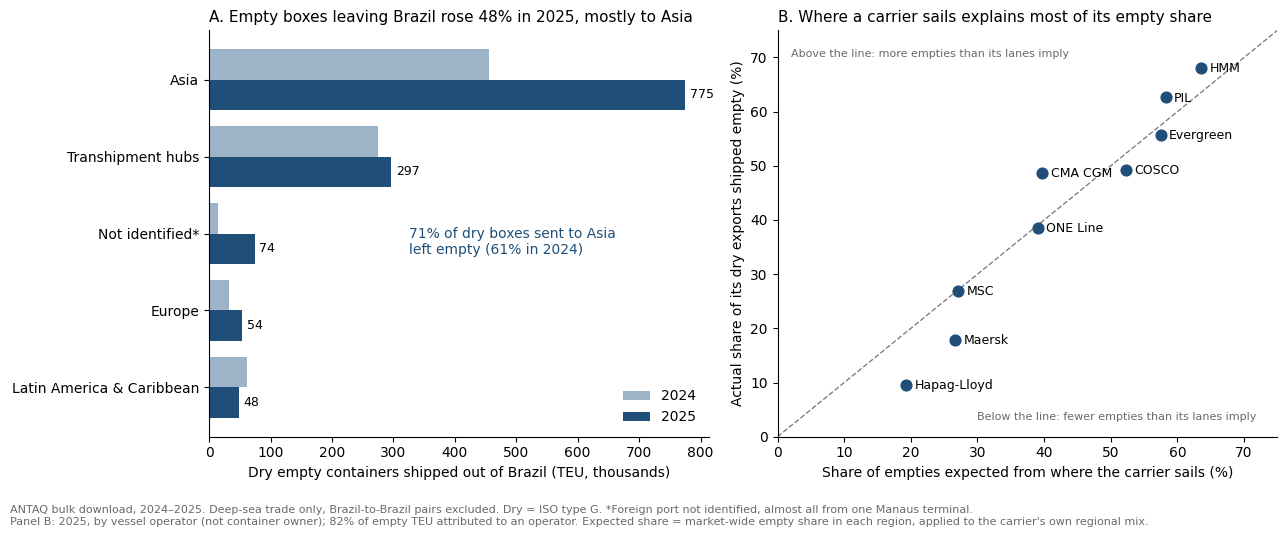

In [7]:
# 6 — Figure for the README and the post (fig09)
FIG_DIR = BASE / "outputs" / "figures"

order = ["Asia", "Transhipment hub", "Not identified", "Europe", "Latin America & Caribbean"]
labels = ["Asia", "Transhipment hubs", "Not identified*", "Europe", "Latin America & Caribbean"]
dry_empty = by_region_year(is_exp & is_dry & is_empty).loc[order, [2024, 2025]]

s = (flows[is_exp & is_dry & (flows["region"] == "Asia")]
     .groupby(["year", "state"])["teu"].sum().unstack("state"))
asia_pct = 100 * s["Empty"] / (s["Empty"] + s["Full"])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

y = np.arange(len(order))
ax1.barh(y - 0.2, dry_empty[2024], height=0.4, color="#9db4c8", label="2024")
ax1.barh(y + 0.2, dry_empty[2025], height=0.4, color="#1f4e79", label="2025")
for yi, v in zip(y, dry_empty[2025]):
    ax1.text(v + 8, yi + 0.2, f"{v:,.0f}", va="center", fontsize=9)
ax1.set_yticks(y, labels)
ax1.invert_yaxis()
ax1.set_xlabel("Dry empty containers shipped out of Brazil (TEU, thousands)")
ax1.set_title("A. Empty boxes leaving Brazil rose 48% in 2025, mostly to Asia", loc="left", fontsize=11)
ax1.text(0.40, 0.45, f"{asia_pct[2025]:.0f}% of dry boxes sent to Asia\nleft empty ({asia_pct[2024]:.0f}% in 2024)",
         transform=ax1.transAxes, fontsize=10, color="#1f4e79")
ax1.legend(frameon=False, loc="lower right")

sp = split.loc[MAIN]
lim = [0, 75]
ax2.plot(lim, lim, ls="--", lw=1, color="grey")
ax2.scatter(sp["expected_from_lane_mix_%"], sp["actual_%"], s=60, color="#1f4e79", zorder=3)
for name, r in sp.iterrows():
    ax2.annotate(name, (r["expected_from_lane_mix_%"], r["actual_%"]),
                 xytext=(6, -3), textcoords="offset points", fontsize=9)
ax2.set_xlim(lim)
ax2.set_ylim(lim)
ax2.set_xlabel("Share of empties expected from where the carrier sails (%)")
ax2.set_ylabel("Actual share of its dry exports shipped empty (%)")
ax2.set_title("B. Where a carrier sails explains most of its empty share", loc="left", fontsize=11)
ax2.text(2, 70, "Above the line: more empties than its lanes imply", fontsize=8, color="dimgrey")
ax2.text(30, 3, "Below the line: fewer empties than its lanes imply", fontsize=8, color="dimgrey")

for ax in (ax1, ax2):
    ax.spines[["top", "right"]].set_visible(False)

fig.text(0.01, -0.06,
         "ANTAQ bulk download, 2024–2025. Deep-sea trade only, Brazil-to-Brazil pairs excluded. Dry = ISO type G. "
         "*Foreign port not identified, almost all from one Manaus terminal.\n"
         "Panel B: 2025, by vessel operator (not container owner); 82% of empty TEU attributed to an operator. "
         "Expected share = market-wide empty share in each region, applied to the carrier's own regional mix.",
         fontsize=8, color="dimgrey")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig09_empty_flows.png", dpi=150, bbox_inches="tight")
plt.show()

## What this notebook shows

**The question this project started from:** how many empty containers leave Brazil, where they go, and who carries them.

- **Dry empty exports grew 48% in 2025** (847k → 1,258k TEU), far faster than dry imports (+12%). Asia takes 62% of them, and 775k TEU went there in 2025, up 70%.
- **Seven in ten dry containers sent from Brazil to Asia leave empty** (71% in 2025, 61% in 2024). For China alone it is three in four: almost three empty boxes for every full one. The ratio of full imports to full exports with China barely moved (6.5:1 → 6.6:1). What jumped was the number of empties sent back.
- **Two clusters send most of them out:** the Santos complex (37%) and Santa Catarina (Portonave, Itapoá, Itajaí, 25%). Ports split into three groups: almost pure import ports where most outbound dry boxes are empty (Manaus, Suape, Itaguaí, Pecém), empty-evacuation ports (Portonave 64%, Rio de Janeiro 47%, DP World Santos 42%) and export ports where most leave full (Paranaguá 16%, Itajaí 22%, Santos 26%).
- **Where a carrier sails explains most of how many boxes it ships empty.** On the Asia lane every operator sends 58–80% of dry boxes back empty. Across all lanes the range is 10–68%. Applying the market-wide empty share of each region to each operator's own mix reproduces its actual share closely (r = 0.97 across nine operators). Maersk and Hapag-Lloyd ship about 9–10 points fewer empties than their lanes imply; CMA CGM about 9 points more, mostly through transhipment hubs.

## Limitations

1. **Operator, not owner.** Carriers are assigned by vessel operator. On shared services, partners' boxes count under the operator. 18% of 2025 empty TEU could not be attributed to any operator, and 2024 coverage (54%) is too low for carrier-level results.
2. **Last port, not final destination.** ANTAQ records where a box is loaded or discharged. Empties sent to hubs (24% of the total, Singapore included) may end up in Asia too, so Asia's share is a lower bound.
3. **The maritime balance does not close.** More dry boxes enter than leave by sea every year (see notebook 05), so these figures describe flows, not a build-up or shortage of equipment in Brazil.
4. **No cost figure.** Empty repositioning is measured in TEU and in the share of outbound boxes without cargo. Turning that into dollars would need a repositioning cost per TEU that public data does not provide.
5. **Two years.** Enough to see a sharp change in 2025, not enough to call it a trend.